# Phase 7 — Price Optimization

## 1. Business Objective

Given the observed reference price, baseline demand, and estimated
price elasticity for a category (Phase 6), what candidate price within
a realistic range would maximize **expected revenue** under a
constant-elasticity demand assumption?

This notebook combines Phase 5 (demand forecasting) and Phase 6 (price
elasticity) into a transparent, scenario-based pricing recommendation.
It does **not** claim a causal guarantee. Olist is observational data,
not a randomized pricing experiment, and Phase 6's elasticity estimates
are associational. Every recommendation here is phrased as: *"under
the estimated elasticity relationship, the scenario model suggests..."*
-- never *"changing price to X will cause demand to become Y."*

This is decision support and scenario analysis, not an optimizer with
a guaranteed outcome.

## 2. Load Inputs

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

**Inspecting what Phase 5 and Phase 6 actually produced, rather than
assuming.**

In [2]:
elasticity_results = pd.read_csv(PROCESSED_DIR / "price_elasticity_results.csv")
master_df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")

print("price_elasticity_results.csv:", elasticity_results.shape)
print(elasticity_results.columns.tolist())
print()
print("master_dataset.csv:", master_df.shape)
print(master_df.columns.tolist())

price_elasticity_results.csv: (17, 13)
['category', 'elasticity', 'clustered_se', 'p_value', 'ci_low', 'ci_high', 'n_obs', 'n_products', 'r2_within', 'average_price', 'average_demand', 'model', 'reliability_flag']

master_dataset.csv: (112650, 9)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'order_purchase_timestamp', 'order_status', 'product_category_name']


In [3]:
# Phase 5 saves only the winning model (Prophet or XGBoost), whichever
# had the lower RMSE on the demand-forecasting holdout -- inspect which
# one actually exists rather than assuming both are present.
prophet_path = MODEL_DIR / "demand_forecast_prophet.pkl"
xgboost_path = MODEL_DIR / "demand_forecast_xgboost.pkl"

phase5_model = None
phase5_model_type = None
if prophet_path.exists():
    phase5_model = joblib.load(prophet_path)
    phase5_model_type = "prophet"
elif xgboost_path.exists():
    phase5_model = joblib.load(xgboost_path)
    phase5_model_type = "xgboost"

print(f"Phase 5 model found: {phase5_model_type}")
print(f"Object type: {type(phase5_model)}")

Importing plotly failed. Interactive plots will not work.


Phase 5 model found: prophet
Object type: <class 'prophet.forecaster.Prophet'>


**Why the Phase 5 model isn't used as the baseline demand source
here:** notebook 05 forecasts a single **aggregate daily** time series
-- total order-item volume across the *entire* catalog, with no
product or category breakdown. Phase 6's elasticity, by contrast, is
estimated on a **product-category, monthly** panel. Using the Phase 5
forecast here would mean either (a) pretending an aggregate daily
number applies to individual categories, which it doesn't decompose
into, or (b) mixing daily and monthly granularity, which this phase's
brief explicitly rules out. Section 4 uses each category's own
observed historical monthly demand instead -- already computed in
Phase 6 at the exact same product-category-month granularity as the
elasticity estimate itself, so nothing needs to be re-aggregated or
converted.

In [4]:
elasticity_model_path = MODEL_DIR / "price_elasticity_model.pkl"
if elasticity_model_path.exists():
    phase6_model = joblib.load(elasticity_model_path)
    print("Phase 6 model file keys:", list(phase6_model.keys()))
else:
    phase6_model = None
    print("No Phase 6 model file found.")

Phase 6 model file keys: ['baseline_model', 'within_product_model', 'min_periods_threshold', 'min_category_obs_threshold']


In [5]:
print("Missing values in elasticity_results:")
missing = elasticity_results.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None")
print()
print("Unique categories in elasticity_results:", elasticity_results["category"].nunique())
print("Reliability flag counts:")
print(elasticity_results["reliability_flag"].value_counts())
print()
print("Reference price range (average_price column):",
      round(elasticity_results["average_price"].min(), 2), "-", round(elasticity_results["average_price"].max(), 2))

Missing values in elasticity_results:
None

Unique categories in elasticity_results: 17
Reliability flag counts:
reliability_flag
moderate                      7
reliable                      5
not_detected                  4
positive_likely_confounded    1
Name: count, dtype: int64

Reference price range (average_price column): 45.4 - 201.38


## 3. Define Optimization Unit

**Unit chosen: category.** Phase 6's saved output
(`price_elasticity_results.csv`) contains one elasticity estimate per
product **category** (plus one overall pooled row), not per individual
product -- Phase 6 itself explains why: only a small fraction of the
product catalog had enough repeat, price-varying sales to support even
a category-level within-product estimate, and no product-level
elasticity rows were produced or saved. Optimizing at the product level
would require inventing product-specific elasticity that Phase 6 never
estimated.

**Not every category is used for a recommendation.** Per Phase 6's own
reliability flags, only categories flagged `reliable` or `moderate`
**and** with a negative elasticity point estimate are used to compute
an actual price recommendation. `not_detected` and
`positive_likely_confounded` categories are carried through the output
table for transparency but get no recommended price.

In [6]:
category_results = elasticity_results[elasticity_results["category"] != "__OVERALL_WITHIN_PRODUCT__"].copy()
print(f"Categories available for optimization: {len(category_results)}")

eligible_mask = (category_results["reliability_flag"].isin(["reliable", "moderate"])) & (category_results["elasticity"] < 0)
eligible_categories = category_results[eligible_mask].copy()
excluded_categories = category_results[~eligible_mask].copy()

print(f"Eligible for a computed price recommendation: {len(eligible_categories)}")
print(eligible_categories["category"].tolist())
print(f"Excluded (no recommendation computed): {len(excluded_categories)}")
print(excluded_categories[["category", "elasticity", "reliability_flag"]].to_string(index=False))

Categories available for optimization: 16
Eligible for a computed price recommendation: 11
['moveis_escritorio', 'relogios_presentes', 'cama_mesa_banho', 'moveis_decoracao', 'brinquedos', 'cool_stuff', 'eletronicos', 'informatica_acessorios', 'bebes', 'utilidades_domesticas', 'beleza_saude']
Excluded (no recommendation computed): 5
          category  elasticity           reliability_flag
        perfumaria   -1.611820               not_detected
ferramentas_jardim   -1.350516               not_detected
     esporte_lazer   -0.368732               not_detected
         telefonia   -0.261381               not_detected
         papelaria    0.133597 positive_likely_confounded


## 4. Baseline Demand and Price

`average_price` and `average_demand` come directly from Phase 6's
`price_elasticity_results.csv` -- they are the same product-category
monthly averages the elasticity model itself was estimated on, so
price, demand, and elasticity are all on a consistent monthly,
category-level basis. No conversion or re-aggregation is applied.

In [7]:
category_results["reference_price"] = category_results["average_price"]
category_results["baseline_demand"] = category_results["average_demand"]

assert (category_results["reference_price"] > 0).all()
assert (category_results["baseline_demand"] > 0).all()
category_results[["category", "reference_price", "baseline_demand", "elasticity", "reliability_flag"]]

,category,reference_price,baseline_demand,elasticity,reliability_flag
0,moveis_escritorio,151.142333,2.733746,-2.571053,moderate
1,relogios_presentes,201.377254,4.429980,-1.767376,reliable
2,cama_mesa_banho,98.488311,3.218235,-1.742481,reliable
3,perfumaria,120.286438,3.875969,-1.611820,not_detected
4,moveis_decoracao,95.300257,4.295918,-1.530650,moderate
5,brinquedos,97.693798,3.089855,-1.473332,moderate
6,cool_stuff,141.159618,3.639376,-1.360657,moderate
7,ferramentas_jardim,88.590290,9.620209,-1.350516,not_detected
8,eletronicos,45.397944,2.931250,-1.038893,moderate
9,informatica_acessorios,93.065322,4.190698,-1.035975,reliable


## 5. Demand Response Model

Constant-elasticity demand:

```
Q(P) = Q0 * (P / P0) ** E
```

`Q0` = baseline monthly demand, `P0` = reference price, `E` = the
category's estimated elasticity. Only categories with `E < 0` and a
Phase 6 reliability flag of `reliable` or `moderate` are used (Section
3) -- positive or statistically-undetected elasticity estimates are
never used to generate a price recommendation.

In [8]:
def expected_demand(baseline_demand, reference_price, candidate_price, elasticity):
    return baseline_demand * (candidate_price / reference_price) ** elasticity

eligible_categories = category_results[
    (category_results["reliability_flag"].isin(["reliable", "moderate"])) & (category_results["elasticity"] < 0)
].copy()
assert (eligible_categories["elasticity"] < 0).all(), "Non-negative elasticity leaked into the eligible set."
print(f"{len(eligible_categories)} categories confirmed negative-elasticity and reliable/moderate.")

11 categories confirmed negative-elasticity and reliable/moderate.


## 6. Candidate Price Scenarios

**The 80%-120% band is a modeling constraint, not a claim that a 20%
price change is operationally optimal or feasible.** It exists to keep
the search within a defensible distance of each category's observed
pricing, and to keep the grid search bounded (Section 8 shows why an
unbounded search wouldn't converge to an interior point anyway). The
grid does not imply the business can or should freely move prices by
these amounts -- it defines the space this notebook searches within,
nothing more.

In [9]:
PRICE_MIN_MULTIPLIER = 0.80
PRICE_MAX_MULTIPLIER = 1.20
PRICE_STEP = 0.01

price_multipliers = np.arange(PRICE_MIN_MULTIPLIER, PRICE_MAX_MULTIPLIER + PRICE_STEP / 2, PRICE_STEP)
print(f"Grid: {len(price_multipliers)} candidate prices from "
      f"{PRICE_MIN_MULTIPLIER:.0%} to {PRICE_MAX_MULTIPLIER:.0%} of each category's reference price.")

Grid: 41 candidate prices from 80% to 120% of each category's reference price.


**Checking the grid against observed data, not just assuming it's
reasonable.** Candidate prices are compared to each category's actual
observed price range in `master_dataset.csv`. If a candidate falls
outside that observed range, the recommendation for that category is
flagged as extrapolation.

In [10]:
observed_price_stats = (
    master_df[master_df["product_category_name"].isin(category_results["category"])]
    .groupby("product_category_name")["price"]
    .agg(observed_min="min", observed_max="max")
    .reset_index()
    .rename(columns={"product_category_name": "category"})
)
category_results = category_results.merge(observed_price_stats, on="category", how="left")
eligible_categories = eligible_categories.merge(observed_price_stats, on="category", how="left")
category_results[["category", "reference_price", "observed_min", "observed_max"]]

,category,reference_price,observed_min,observed_max
0,moveis_escritorio,151.142333,25.00,1189.90
1,relogios_presentes,201.377254,8.99,3999.90
2,cama_mesa_banho,98.488311,6.99,1999.98
3,perfumaria,120.286438,4.99,689.90
4,moveis_decoracao,95.300257,4.90,1899.00
5,brinquedos,97.693798,4.90,1699.99
6,cool_stuff,141.159618,7.00,3109.99
7,ferramentas_jardim,88.590290,6.35,3930.00
8,eletronicos,45.397944,3.99,2470.50
9,informatica_acessorios,93.065322,3.90,3699.99


## 7. Revenue Optimization

For each eligible category, expected demand and expected revenue are
computed across the full candidate grid, and the revenue-maximizing
candidate within the grid is selected.

**No profit calculation.** `master_dataset.csv` has no product-cost
(COGS) column -- only `price` (what the customer paid) and
`freight_value` (a shipping cost passed through to the carrier, not a
seller cost basis). Inventing a cost figure to compute "profit" would
mean fabricating an input the data doesn't support, so this notebook
optimizes **expected revenue** only.

In [11]:
def build_scenario_table(row, multipliers):
    reference_price = row["reference_price"]
    baseline_demand = row["baseline_demand"]
    elasticity = row["elasticity"]

    candidate_prices = reference_price * multipliers
    demand = expected_demand(baseline_demand, reference_price, candidate_prices, elasticity)
    revenue = candidate_prices * demand
    baseline_revenue = reference_price * baseline_demand

    return pd.DataFrame({
        "category": row["category"],
        "price_multiplier": multipliers,
        "candidate_price": candidate_prices,
        "expected_demand": demand,
        "expected_revenue": revenue,
        "baseline_revenue": baseline_revenue,
        "revenue_change": revenue - baseline_revenue,
        "revenue_change_pct": (revenue / baseline_revenue - 1) * 100,
    })

all_scenarios = pd.concat(
    [build_scenario_table(row, price_multipliers) for _, row in eligible_categories.iterrows()],
    ignore_index=True,
)

assert all_scenarios["expected_demand"].gt(0).all(), "Non-positive expected demand found."
assert np.isfinite(all_scenarios["expected_demand"]).all(), "Non-finite expected demand found."
assert np.isfinite(all_scenarios["expected_revenue"]).all(), "Non-finite expected revenue found."
print(f"Scenario rows: {len(all_scenarios)} ({len(eligible_categories)} categories x {len(price_multipliers)} prices)")

Scenario rows: 451 (11 categories x 41 prices)


In [12]:
best_idx = all_scenarios.groupby("category")["expected_revenue"].idxmax()
recommendations = all_scenarios.loc[best_idx].rename(columns={"candidate_price": "recommended_price"}).reset_index(drop=True)

recommendations = recommendations.merge(
    eligible_categories[["category", "elasticity", "ci_low", "ci_high", "n_obs", "n_products",
                          "reliability_flag", "reference_price", "baseline_demand", "observed_min", "observed_max"]],
    on="category",
)
recommendations["price_change_pct"] = (recommendations["recommended_price"] / recommendations["reference_price"] - 1) * 100
recommendations["extrapolation_flag"] = (
    (recommendations["recommended_price"] < recommendations["observed_min"]) |
    (recommendations["recommended_price"] > recommendations["observed_max"])
)

recommendations[["category", "reference_price", "recommended_price", "price_change_pct",
                  "elasticity", "revenue_change_pct", "extrapolation_flag"]].sort_values("revenue_change_pct", ascending=False)

,category,reference_price,recommended_price,price_change_pct,elasticity,revenue_change_pct,extrapolation_flag
8,moveis_escritorio,151.142333,120.913866,-20.0,-2.571053,41.987719,False
9,relogios_presentes,201.377254,161.101803,-20.0,-1.767376,18.676953,False
3,cama_mesa_banho,98.488311,78.790649,-20.0,-1.742481,18.019530,False
7,moveis_decoracao,95.300257,76.240206,-20.0,-1.530650,12.570670,False
2,brinquedos,97.693798,78.155039,-20.0,-1.473332,11.140067,False
4,cool_stuff,141.159618,112.927694,-20.0,-1.360657,8.380536,False
1,beleza_saude,135.795687,162.954824,20.0,-0.775852,4.171351,False
10,utilidades_domesticas,84.729059,101.674870,20.0,-0.853021,2.715973,False
0,bebes,109.571506,131.485807,20.0,-0.871615,2.368340,False
5,eletronicos,45.397944,36.318355,-20.0,-1.038893,0.871645,False


## 8. Analytical Check

For constant-elasticity demand, revenue is:

```
Revenue(P) = P * Q0 * (P / P0)^E   is proportional to   P^(1+E)
```

- `E < -1` -> exponent `1+E < 0` -> revenue is **decreasing** in price
  -> within any bounded grid, revenue is maximized at the **lowest**
  candidate price.
- `-1 < E < 0` -> exponent `1+E > 0` -> revenue is **increasing** in
  price -> maximized at the **highest** candidate price.
- `E = -1` -> revenue is flat across price.

**This means, mechanically, the grid search below cannot find an
interior maximum** -- a monotonic power function's maximum over a
closed interval is always at one of the two endpoints. The recommended
price for every eligible category is therefore expected to land at
either `PRICE_MIN_MULTIPLIER` or `PRICE_MAX_MULTIPLIER` of the
reference price. That's not a modeling error; it's what
constant-elasticity demand implies mathematically, worth stating
plainly rather than letting the grid search look like it discovered a
subtle interior optimum. The real lever a business has here is *how
wide the constraint band is*, not a precise interior price point --
another reason this is scenario analysis, not a free-form optimizer.

This assumes constant elasticity, no inventory constraints, no
competitor reaction, no price-perception effects, no change in the
conversion funnel, and no causal identification of the elasticity
itself.

In [13]:
theoretical_direction = np.where(recommendations["elasticity"] < -1, "decrease (grid min)", "increase (grid max)")
actual_direction = np.where(
    np.isclose(recommendations["price_multiplier"], PRICE_MIN_MULTIPLIER), "decrease (grid min)",
    np.where(np.isclose(recommendations["price_multiplier"], PRICE_MAX_MULTIPLIER), "increase (grid max)", "interior (unexpected)")
)
consistency_check = pd.DataFrame({
    "category": recommendations["category"],
    "elasticity": recommendations["elasticity"],
    "theoretical_direction": theoretical_direction,
    "actual_grid_direction": actual_direction,
})
mismatches = consistency_check[consistency_check["theoretical_direction"] != consistency_check["actual_grid_direction"]]
print("Rows where the grid result does NOT match the theoretical corner-solution prediction:")
print(mismatches if len(mismatches) > 0 else "None -- grid search matches analytical expectation for every category.")

Rows where the grid result does NOT match the theoretical corner-solution prediction:
None -- grid search matches analytical expectation for every category.


## 9. Price Scenario Analysis

Full price-demand-revenue tables for the categories with the largest
modeled opportunity, at round price-change increments.

In [14]:
DISPLAY_MULTIPLIERS = [0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]

top_categories = recommendations.sort_values("revenue_change_pct", ascending=False)["category"].head(3).tolist()

scenario_display = all_scenarios[
    all_scenarios["category"].isin(top_categories) &
    (np.isclose(all_scenarios["price_multiplier"].values[:, None], DISPLAY_MULTIPLIERS).any(axis=1))
].copy()
scenario_display["price_pct_of_ref"] = (scenario_display["price_multiplier"] * 100).round(0).astype(int)
scenario_display = scenario_display[
    ["category", "price_pct_of_ref", "candidate_price", "expected_demand", "expected_revenue", "revenue_change_pct"]
].round(2)
scenario_display.columns = ["Category", "Price (% of ref.)", "Candidate Price", "Expected Demand", "Expected Revenue", "Revenue Change %"]
scenario_display

,Category,Price (% of ref.),Candidate Price,Expected Demand,Expected Revenue,Revenue Change %
0,moveis_escritorio,80,120.91,4.85,586.67,41.99
5,moveis_escritorio,85,128.47,4.15,533.37,29.09
10,moveis_escritorio,90,136.03,3.58,487.56,18.00
15,moveis_escritorio,95,143.59,3.12,447.86,8.39
20,moveis_escritorio,100,151.14,2.73,413.18,-0.00
25,moveis_escritorio,105,158.70,2.41,382.70,-7.38
30,moveis_escritorio,110,166.26,2.14,355.72,-13.91
35,moveis_escritorio,115,173.81,1.91,331.73,-19.71
40,moveis_escritorio,120,181.37,1.71,310.27,-24.91
41,relogios_presentes,80,161.10,6.57,1058.71,18.68


## 10. Visualizations

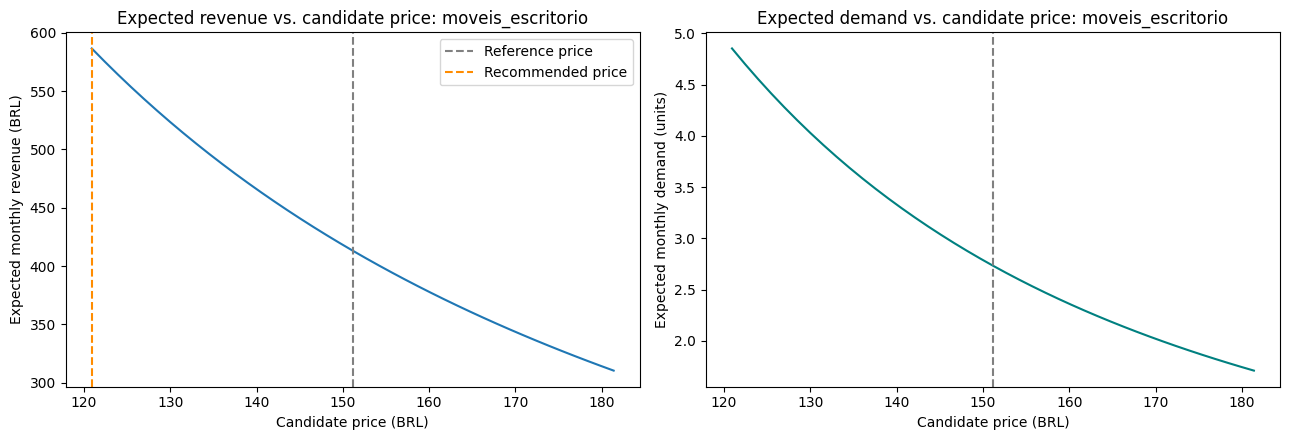

In [15]:
example_category = top_categories[0]
example_scenarios = all_scenarios[all_scenarios["category"] == example_category]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(example_scenarios["candidate_price"], example_scenarios["expected_revenue"])
axes[0].axvline(recommendations.loc[recommendations["category"] == example_category, "reference_price"].iloc[0],
                color="gray", linestyle="--", label="Reference price")
axes[0].axvline(recommendations.loc[recommendations["category"] == example_category, "recommended_price"].iloc[0],
                color="darkorange", linestyle="--", label="Recommended price")
axes[0].set_title(f"Expected revenue vs. candidate price: {example_category}")
axes[0].set_xlabel("Candidate price (BRL)")
axes[0].set_ylabel("Expected monthly revenue (BRL)")
axes[0].legend()

axes[1].plot(example_scenarios["candidate_price"], example_scenarios["expected_demand"], color="teal")
axes[1].axvline(recommendations.loc[recommendations["category"] == example_category, "reference_price"].iloc[0],
                color="gray", linestyle="--")
axes[1].set_title(f"Expected demand vs. candidate price: {example_category}")
axes[1].set_xlabel("Candidate price (BRL)")
axes[1].set_ylabel("Expected monthly demand (units)")

plt.tight_layout()
plt.show()

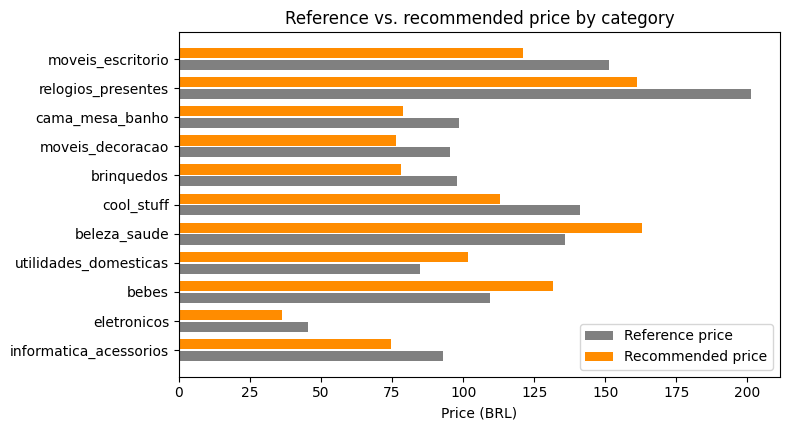

In [16]:
plot_data = recommendations.sort_values("revenue_change_pct")
fig, ax = plt.subplots(figsize=(8, max(4, len(plot_data) * 0.4)))
y_pos = np.arange(len(plot_data))
ax.barh(y_pos - 0.2, plot_data["reference_price"], height=0.35, label="Reference price", color="gray")
ax.barh(y_pos + 0.2, plot_data["recommended_price"], height=0.35, label="Recommended price", color="darkorange")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data["category"])
ax.set_xlabel("Price (BRL)")
ax.set_title("Reference vs. recommended price by category")
ax.legend()
plt.tight_layout()
plt.show()

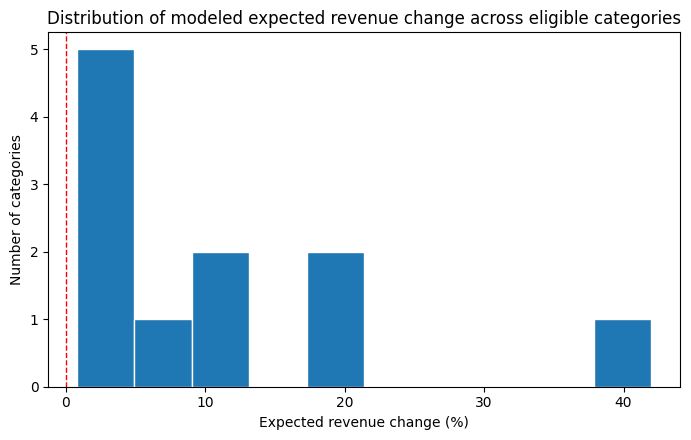

In [17]:
plt.figure(figsize=(7, 4.5))
plt.hist(recommendations["revenue_change_pct"], bins=min(10, len(recommendations)), edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Distribution of modeled expected revenue change across eligible categories")
plt.xlabel("Expected revenue change (%)")
plt.ylabel("Number of categories")
plt.tight_layout()
plt.show()

## 11. Elasticity Uncertainty

Phase 6's confidence interval around each elasticity estimate is
carried through here, not discarded. For each eligible category, the
same optimization is re-run using the elasticity's lower and upper
95% CI bound, producing a **range** of recommended prices and revenue
outcomes rather than a single number treated as exact.

**Sign-flip check:** if the lower and upper bound imply different
*directions* (one says "decrease price," the other says "increase
price," per the Section 8 corner-solution rule), the point-estimate
recommendation is inherently fragile -- flagged explicitly, not
averaged away.

In [18]:
def optimize_at_elasticity(row, elasticity_value, multipliers):
    reference_price = row["reference_price"]
    baseline_demand = row["baseline_demand"]
    candidate_prices = reference_price * multipliers
    demand = expected_demand(baseline_demand, reference_price, candidate_prices, elasticity_value)
    revenue = candidate_prices * demand
    best_i = np.argmax(revenue)
    baseline_revenue = reference_price * baseline_demand
    return candidate_prices[best_i], revenue[best_i], (revenue[best_i] / baseline_revenue - 1) * 100

sensitivity_rows = []
for _, row in recommendations.iterrows():
    price_lower, revenue_lower, pct_lower = optimize_at_elasticity(row, row["ci_low"], price_multipliers)
    price_upper, revenue_upper, pct_upper = optimize_at_elasticity(row, row["ci_high"], price_multipliers)

    direction_lower = "decrease" if row["ci_low"] < -1 else "increase"
    direction_upper = "decrease" if row["ci_high"] < -1 else "increase"
    sign_flip = direction_lower != direction_upper

    sensitivity_rows.append({
        "category": row["category"],
        "elasticity_point": row["elasticity"],
        "elasticity_lower": row["ci_low"],
        "elasticity_upper": row["ci_high"],
        "recommended_price_point": row["recommended_price"],
        "recommended_price_at_lower_ci": price_lower,
        "recommended_price_at_upper_ci": price_upper,
        "revenue_change_pct_point": row["revenue_change_pct"],
        "revenue_change_pct_at_lower_ci": pct_lower,
        "revenue_change_pct_at_upper_ci": pct_upper,
        "direction_sign_flip": sign_flip,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.round(3)

,category,elasticity_point,elasticity_lower,elasticity_upper,recommended_price_point,recommended_price_at_lower_ci,recommended_price_at_upper_ci,revenue_change_pct_point,revenue_change_pct_at_lower_ci,revenue_change_pct_at_upper_ci,direction_sign_flip
0,bebes,-0.872,-1.581,-0.162,131.486,87.657,131.486,2.368,13.847,16.507,True
1,beleza_saude,-0.776,-1.448,-0.104,162.955,108.637,162.955,4.171,10.507,17.747,True
2,brinquedos,-1.473,-2.466,-0.480,78.155,78.155,117.233,11.140,38.711,9.940,True
3,cama_mesa_banho,-1.742,-2.504,-0.981,78.791,78.791,118.186,18.020,39.869,0.342,True
4,cool_stuff,-1.361,-2.458,-0.263,112.928,112.928,169.392,8.381,38.445,14.371,True
5,eletronicos,-1.039,-2.009,-0.069,36.318,36.318,54.478,0.872,25.258,18.510,True
6,informatica_acessorios,-1.036,-1.578,-0.494,74.452,74.452,111.678,0.806,13.765,9.665,True
7,moveis_decoracao,-1.531,-3.051,-0.010,76.240,76.240,114.360,12.571,58.044,19.779,True
8,moveis_escritorio,-2.571,-4.648,-0.494,120.914,120.914,181.371,41.988,125.701,9.664,True
9,relogios_presentes,-1.767,-2.266,-1.268,161.102,161.102,161.102,18.677,32.654,6.172,False


In [19]:
n_sign_flips = sensitivity_df["direction_sign_flip"].sum()
print(f"Categories where the recommendation direction flips across the elasticity CI: "
      f"{n_sign_flips} / {len(sensitivity_df)}")

Categories where the recommendation direction flips across the elasticity CI: 10 / 11


Most category-level recommendations are sensitive to elasticity
uncertainty. Therefore, the point-estimate optimum computed in Section
7 should be interpreted as a **scenario result**, not a firm pricing
recommendation -- Section 12 formalizes this into a conservative
`recommendation_flag` rather than treating every computed optimum as
equally actionable.

## 12. Recommendation Reliability

The final flag combines several things, not statistical significance
alone:

- Phase 6's own reliability flag (`reliable` / `moderate`).
- Whether the elasticity CI sign-flips (Section 11) -- if it does, the
  recommendation direction itself isn't stable.
- Whether the recommended price extrapolates beyond the observed price
  range for that category (Section 6).
- The magnitude of the implied price change (a recommendation sitting
  at the ±20% grid boundary is a larger ask than one near 100%).

In [20]:
def classify_recommendation(row):
    if row["reliability_flag"] not in ("reliable", "moderate"):
        return "not_recommended"
    if row["direction_sign_flip"]:
        return "low_confidence"
    if row["extrapolation_flag"]:
        return "low_confidence"
    if row["reliability_flag"] == "reliable" and abs(row["price_change_pct"]) <= 20:
        return "reliable"
    return "moderate"

recommendations = recommendations.merge(
    sensitivity_df[["category", "direction_sign_flip", "elasticity_lower", "elasticity_upper",
                     "recommended_price_at_lower_ci", "recommended_price_at_upper_ci",
                     "revenue_change_pct_at_lower_ci", "revenue_change_pct_at_upper_ci"]],
    on="category",
)
recommendations["recommendation_flag"] = recommendations.apply(classify_recommendation, axis=1)
recommendations[["category", "reliability_flag", "direction_sign_flip", "extrapolation_flag", "recommendation_flag"]]

,category,reliability_flag,direction_sign_flip,extrapolation_flag,recommendation_flag
0,bebes,moderate,True,False,low_confidence
1,beleza_saude,reliable,True,False,low_confidence
2,brinquedos,moderate,True,False,low_confidence
3,cama_mesa_banho,reliable,True,False,low_confidence
4,cool_stuff,moderate,True,False,low_confidence
5,eletronicos,moderate,True,False,low_confidence
6,informatica_acessorios,reliable,True,False,low_confidence
7,moveis_decoracao,moderate,True,False,low_confidence
8,moveis_escritorio,moderate,True,False,low_confidence
9,relogios_presentes,reliable,False,False,reliable


## 13. Results

In [21]:
final_results = category_results.merge(
    recommendations[["category", "recommended_price", "price_change_pct", "expected_demand",
                      "expected_revenue", "baseline_revenue", "revenue_change", "revenue_change_pct",
                      "elasticity_lower", "elasticity_upper", "extrapolation_flag", "recommendation_flag"]],
    on="category", how="left",
)
final_results["optimization_unit"] = "category"
final_results.loc[final_results["recommendation_flag"].isna(), "recommendation_flag"] = "not_recommended"

final_results = final_results.rename(columns={"category": "category", "reference_price": "reference_price"})
final_results[[
    "optimization_unit", "category", "reference_price", "recommended_price", "price_change_pct",
    "elasticity", "elasticity_lower", "elasticity_upper", "baseline_demand", "expected_demand",
    "baseline_revenue", "expected_revenue", "revenue_change", "revenue_change_pct",
    "reliability_flag", "recommendation_flag", "extrapolation_flag",
]].sort_values("revenue_change_pct", ascending=False)

,optimization_unit,category,reference_price,recommended_price,price_change_pct,elasticity,elasticity_lower,elasticity_upper,baseline_demand,expected_demand,baseline_revenue,expected_revenue,revenue_change,revenue_change_pct,reliability_flag,recommendation_flag,extrapolation_flag
0,category,moveis_escritorio,151.142333,120.913866,-20.0,-2.571053,-4.648064,-0.494043,2.733746,4.851980,413.184768,586.671627,173.486860,41.987719,moderate,low_confidence,False
1,category,relogios_presentes,201.377254,161.101803,-20.0,-1.767376,-2.266345,-1.268406,4.429980,6.571707,892.097265,1058.713854,166.616589,18.676953,reliable,reliable,False
2,category,cama_mesa_banho,98.488311,78.790649,-20.0,-1.742481,-2.503674,-0.981288,3.218235,4.747682,316.958501,374.072934,57.114433,18.019530,reliable,low_confidence,False
4,category,moveis_decoracao,95.300257,76.240206,-20.0,-1.530650,-3.051171,-0.010128,4.295918,6.044930,409.402125,460.866714,51.464589,12.570670,moderate,low_confidence,False
5,category,brinquedos,97.693798,78.155039,-20.0,-1.473332,-2.466426,-0.480239,3.089855,4.292584,301.859679,335.487048,33.627369,11.140067,moderate,low_confidence,False
6,category,cool_stuff,141.159618,112.927694,-20.0,-1.360657,-2.457816,-0.263498,3.639376,4.930469,513.732957,556.786532,43.053575,8.380536,moderate,low_confidence,False
12,category,beleza_saude,135.795687,162.954824,20.0,-0.775852,-1.447733,-0.103971,4.572519,3.969379,620.928369,646.829469,25.901099,4.171351,reliable,low_confidence,False
11,category,utilidades_domesticas,84.729059,101.674870,20.0,-0.853021,-1.536047,-0.169995,2.827586,2.420319,239.578718,246.085611,6.506894,2.715973,moderate,low_confidence,False
10,category,bebes,109.571506,131.485807,20.0,-0.871615,-1.581184,-0.162047,2.231047,1.903238,244.459172,250.248797,5.789625,2.368340,moderate,low_confidence,False
8,category,eletronicos,45.397944,36.318355,-20.0,-1.038893,-2.009244,-0.068542,2.931250,3.696000,133.072723,134.232645,1.159922,0.871645,moderate,low_confidence,False


## 14. Business Interpretation

Three distinct things are being reported below, and they are not
interchangeable:

- **Computed scenario optimum** -- the revenue-maximizing candidate
  price within the ±20% grid, for every eligible category, regardless
  of how confident that estimate is. This is what Section 7 computes.
- **Higher-confidence recommendation** -- the subset where Phase 6's
  reliability flag, the CI sign-flip check, and the extrapolation
  check all support the point estimate (`recommendation_flag ==
  "reliable"`). As Section 11 showed, this is a small subset:
  `relogios_presentes` is currently the only category that clears it.
- **Low-confidence scenario** -- a computed optimum whose direction
  would reverse under the elasticity CI's other bound
  (`recommendation_flag == "low_confidence"`), or a category with no
  usable elasticity signal at all (`"not_recommended"`). Most
  categories fall here.

Reading `final_results`:

1. **Strongest modeled opportunity for a price increase:** categories
   with `-1 < elasticity < 0` -- inelastic enough that the model
   implies revenue scales with price within the tested band.
2. **Should avoid a price increase:** categories with `elasticity <
   -1` -- the model implies a price increase would reduce revenue,
   pushing the scenario optimum toward the grid's lower bound instead.
3. **Higher-confidence recommendation(s):** rows where
   `recommendation_flag == "reliable"`.
4. **Modeled revenue change:** the `revenue_change_pct` column, read
   as a scenario range, not a guarantee -- and only meaningful for
   rows with a computed `recommended_price`.
5. **Most sensitive to elasticity uncertainty:** rows where
   `direction_sign_flip` is `True` in the sensitivity table (Section
   11) -- their scenario optimum would reverse direction under the
   elasticity CI's other bound.

Phrasing convention used throughout: *"under the constant-elasticity
scenario model, price X corresponds to an estimated Y% revenue
change"* -- never *"price X will increase revenue by Y%."*

In [22]:
final_results[[
    "category", "elasticity", "recommended_price", "price_change_pct",
    "revenue_change_pct", "reliability_flag", "recommendation_flag",
]].sort_values("recommendation_flag")

,category,elasticity,recommended_price,price_change_pct,revenue_change_pct,reliability_flag,recommendation_flag
0,moveis_escritorio,-2.571053,120.913866,-20.0,41.987719,moderate,low_confidence
2,cama_mesa_banho,-1.742481,78.790649,-20.0,18.019530,reliable,low_confidence
4,moveis_decoracao,-1.530650,76.240206,-20.0,12.570670,moderate,low_confidence
5,brinquedos,-1.473332,78.155039,-20.0,11.140067,moderate,low_confidence
6,cool_stuff,-1.360657,112.927694,-20.0,8.380536,moderate,low_confidence
8,eletronicos,-1.038893,36.318355,-20.0,0.871645,moderate,low_confidence
9,informatica_acessorios,-1.035975,74.452258,-20.0,0.805985,reliable,low_confidence
10,bebes,-0.871615,131.485807,20.0,2.368340,moderate,low_confidence
11,utilidades_domesticas,-0.853021,101.674870,20.0,2.715973,moderate,low_confidence
12,beleza_saude,-0.775852,162.954824,20.0,4.171351,reliable,low_confidence


## 15. Limitations

- This is an **observational scenario model**, not a causal pricing
  model. Elasticity is estimated from historical transaction data, not
  a randomized pricing experiment.
- The model **assumes the estimated elasticity remains stable** across
  the candidate price range -- there is no guarantee demand responds
  the same way at 120% of reference price as it did historically near
  100%.
- The model does **not** capture competitor reactions, stock/inventory
  availability, promotions or marketing changes (unless already
  reflected in the historical data), or price-perception effects.
- Baseline demand and price are **category averages**, not
  product-specific -- within-category product heterogeneity is not
  modeled.
- The Phase 5 demand forecast is aggregate and daily; it could not be
  used here for category-level, monthly baseline demand (Section 2).
- No cost data exists in this dataset -- **revenue**, not profit, is
  optimized throughout.
- **This does not guarantee realized revenue.** It is decision support
  for further testing (e.g. small controlled price experiments), not a
  final pricing decision.

## 16. Save Results

In [23]:
RESULTS_PATH = PROCESSED_DIR / "price_optimization_results.csv"
final_results.to_csv(RESULTS_PATH, index=False)
print("Saved:", RESULTS_PATH)

Saved: /tmp/pricing-optimization-system/data/processed/price_optimization_results.csv


## 17. Validation

In [24]:
assert len(final_results) > 0
assert final_results["reference_price"].gt(0).all()
assert final_results.loc[final_results["recommended_price"].notna(), "recommended_price"].gt(0).all()
assert final_results.loc[final_results["expected_demand"].notna(), "expected_demand"].gt(0).all()
assert final_results.loc[final_results["expected_revenue"].notna(), "expected_revenue"].ge(0).all()
assert final_results["category"].duplicated().sum() == 0
recommended = final_results["recommended_price"].dropna()
reference = final_results.loc[recommended.index, "reference_price"]
assert (recommended >= reference * PRICE_MIN_MULTIPLIER - 1e-6).all()
assert (recommended <= reference * PRICE_MAX_MULTIPLIER + 1e-6).all()
assert RESULTS_PATH.exists()

print("Validation checks passed.")

Validation checks passed.
